# Exploratory data analysis

This notebook explicitly loads and explores each repository dataset. It intentionally avoids helper functions so every section can be edited and extended. Install with `python -m pip install pandas openpyxl geopandas matplotlib seaborn requests jupyter`.

Documentation rules applied: REFEPS `total` is an aggregate count; `99`, `999`, and `9999` are missing sentinels; BAHRA contains settlements; census-radio metadata documents EPSG:4326.

In [36]:
from pathlib import Path
import os
import re
import unicodedata
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
ROOT = Path(".")
CSV_NA = ["", "NA", "N/A", "null", "NULL"]
print(ROOT.resolve())

C:\Users\anapa\OneDrive\Escritorio\facu\radio


## 1. Enfermería 2023

In [37]:
enfermeria = pd.read_csv(ROOT / "enfermeria-2023.csv", encoding="utf-8", na_values=CSV_NA, dtype={"sexo":"string", "grupo_etareo":"string", "id_provincia_residencia":"Int64", "provincia_residencia":"string", "id_pais_nacimiento":"Int64", "pais_nacimiento":"string", "pais_origen":"string", "id_profesion_referencia":"Int64", "profesion_referencia":"string", "id_pais_formacion":"Int64", "pais_formacion":"string", "id_provincia_formacion":"Int64", "provincia_formacion":"string", "id_institucion_formadora":"Int64", "institucion_formadora":"string", "anio_titulo":"Int64", "total":"Int64", "anio_corte":"Int64"});
for column in ["id_pais_nacimiento", "id_pais_formacion", "id_provincia_residencia", "id_provincia_formacion", "anio_titulo", "id_institucion_formadora"]: enfermeria[column] = enfermeria[column].replace([99,999,9999], pd.NA).astype("Int64")
print(enfermeria.shape); display(enfermeria.head()); display(enfermeria.dtypes.to_frame("dtype"))

(88044, 18)


,sexo,grupo_etareo,id_provincia_residencia,provincia_residencia,id_pais_nacimiento,pais_nacimiento,pais_origen,id_profesion_referencia,profesion_referencia,id_pais_formacion,pais_formacion,id_provincia_formacion,provincia_formacion,id_institucion_formadora,institucion_formadora,anio_titulo,total,anio_corte
0,F,35-39,14,Córdoba,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2010,1,2023
1,F,35-39,14,Córdoba,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2015,1,2023
2,F,35-39,22,Chaco,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2023,1,2023
3,F,35-39,30,Entre Ríos,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2009,1,2023
4,F,35-39,30,Entre Ríos,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2010,1,2023


,dtype
sexo,string
grupo_etareo,string
id_provincia_residencia,Int64
provincia_residencia,string
id_pais_nacimiento,Int64
pais_nacimiento,string
pais_origen,string
id_profesion_referencia,Int64
profesion_referencia,string
id_pais_formacion,Int64


In [38]:
enfermeria_missing = enfermeria.isna().sum().to_frame("missing"); enfermeria_missing["missing_pct"] = enfermeria_missing["missing"] / len(enfermeria) * 100; display(enfermeria_missing.sort_values("missing", ascending=False)); print("Duplicate rows:", enfermeria.duplicated().sum()); enfermeria_outliers=[]
for column in enfermeria.select_dtypes(include="number").columns:
 values=enfermeria[column].dropna().astype(float); q1,q3=values.quantile([.25,.75]); iqr=q3-q1; lower,upper=q1-1.5*iqr,q3+1.5*iqr; enfermeria_outliers.append([column,q1,q3,lower,upper,int(((values<lower)|(values>upper)).sum())])
display(pd.DataFrame(enfermeria_outliers, columns=["column","q1","q3","lower","upper","outlier_count"]))

,missing,missing_pct
id_provincia_formacion,15354,17.439008
id_pais_formacion,14882,16.902912
id_institucion_formadora,14882,16.902912
id_pais_nacimiento,777,0.882513
grupo_etareo,0,0.000000
sexo,0,0.000000
pais_nacimiento,0,0.000000
pais_origen,0,0.000000
provincia_residencia,0,0.000000
id_provincia_residencia,0,0.000000


Duplicate rows: 0


,column,q1,q3,lower,upper,outlier_count
0,id_provincia_residencia,6.0,50.00,-60.000,116.000,0
1,id_pais_nacimiento,200.0,200.00,200.000,200.000,12832
2,id_profesion_referencia,15.0,32.00,-10.500,57.500,0
3,id_pais_formacion,200.0,200.00,200.000,200.000,408
4,id_provincia_formacion,2.0,30.00,-40.000,72.000,7925
5,id_institucion_formadora,1128.0,1402.75,715.875,1814.875,10326
6,anio_titulo,2006.0,2018.00,1988.000,2036.000,4414
7,total,1.0,3.00,-2.000,6.000,8467
8,anio_corte,2023.0,2023.00,2023.000,2023.000,0


Professionals represented: 285861


,professionals
sexo,
F,233171
M,52689
S/e,1


,professionals
grupo_etareo,
20-24,2547
25-29,19486
30-34,35393
35-39,39121
40-44,39990
45-49,34171
50-54,29342
55-59,25325
60-64,22371


,professionals
provincia_residencia,
Buenos Aires,116390
Ciudad Autónoma de Buenos Aires,26074
Santa Fe,18121
Córdoba,16904
Mendoza,11656
Entre Ríos,11297
Salta,10054
Tucumán,9972
Chaco,8688


,professionals
pais_origen,
Argentina,268462
Extranjero,16475
Desconocido,924


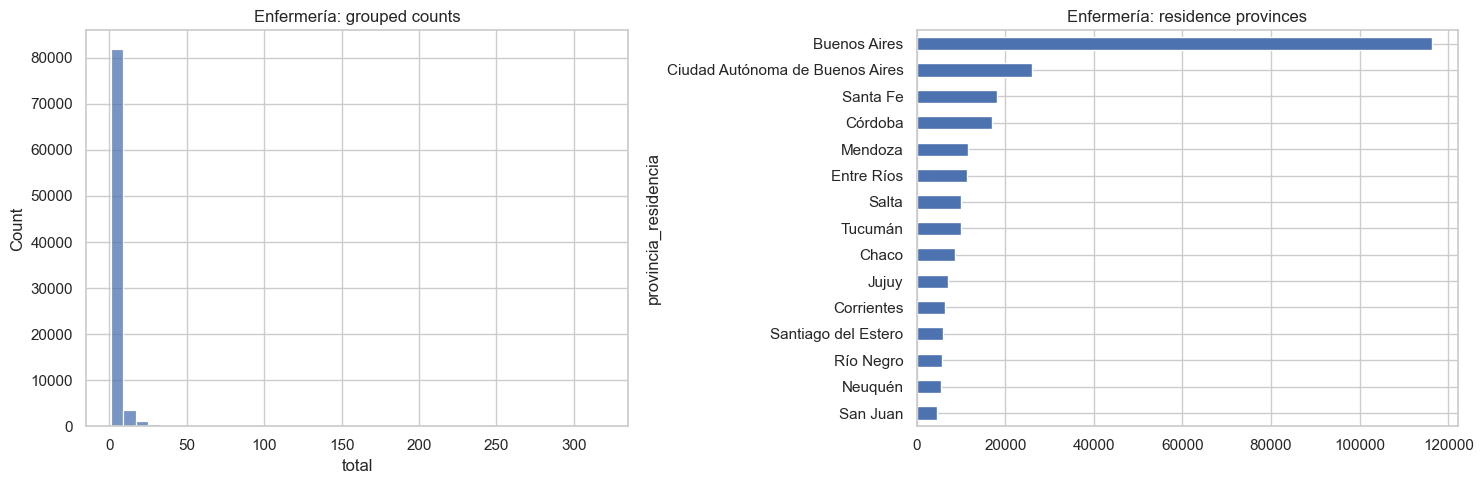

In [39]:
print("Professionals represented:", enfermeria["total"].sum()); display(enfermeria.groupby("sexo",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); display(enfermeria.groupby("grupo_etareo",dropna=False)["total"].sum().sort_index().to_frame("professionals")); display(enfermeria.groupby("provincia_residencia",dropna=False)["total"].sum().sort_values(ascending=False).head(15).to_frame("professionals")); display(enfermeria.groupby("pais_origen",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); fig,axes=plt.subplots(1,2,figsize=(15,5)); sns.histplot(data=enfermeria,x="total",bins=40,ax=axes[0]); axes[0].set_title("Enfermería: grouped counts"); enfermeria.groupby("provincia_residencia")["total"].sum().sort_values(ascending=False).head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Enfermería: residence provinces"); plt.tight_layout(); plt.show()

## 2. Medicina 2023

In [40]:
medicos = pd.read_csv(ROOT / "medicos-2023.csv", encoding="utf-8", na_values=CSV_NA, dtype={"sexo":"string", "grupo_etareo":"string", "id_provincia_residencia":"Int64", "provincia_residencia":"string", "id_pais_nacimiento":"Int64", "pais_nacimiento":"string", "pais_origen":"string", "id_profesion_referencia":"Int64", "profesion_referencia":"string", "id_pais_formacion":"Int64", "pais_formacion":"string", "id_provincia_formacion":"Int64", "provincia_formacion":"string", "id_institucion_formadora":"Int64", "institucion_formadora":"string", "anio_titulo":"Int64", "total":"Int64", "anio_corte":"Int64"});
for column in ["id_pais_nacimiento", "id_pais_formacion", "id_provincia_residencia", "id_provincia_formacion", "anio_titulo", "id_institucion_formadora"]: medicos[column] = medicos[column].replace([99,999,9999], pd.NA).astype("Int64")
print(medicos.shape); display(medicos.head()); display(medicos.dtypes.to_frame("dtype"))

(47219, 18)


,sexo,grupo_etareo,id_provincia_residencia,provincia_residencia,id_pais_nacimiento,pais_nacimiento,pais_origen,id_profesion_referencia,profesion_referencia,id_pais_formacion,pais_formacion,id_provincia_formacion,provincia_formacion,id_institucion_formadora,institucion_formadora,anio_titulo,total,anio_corte
0,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1941,1,2023
1,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1942,1,2023
2,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1946,1,2023
3,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1947,1,2023
4,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1958,1,2023


,dtype
sexo,string
grupo_etareo,string
id_provincia_residencia,Int64
provincia_residencia,string
id_pais_nacimiento,Int64
pais_nacimiento,string
pais_origen,string
id_profesion_referencia,Int64
profesion_referencia,string
id_pais_formacion,Int64


In [41]:
medicos_missing=medicos.isna().sum().to_frame("missing"); medicos_missing["missing_pct"]=medicos_missing["missing"]/len(medicos)*100; display(medicos_missing.sort_values("missing",ascending=False)); print("Duplicate rows:",medicos.duplicated().sum()); medicos_outliers=[]
for column in medicos.select_dtypes(include="number").columns:
 values=medicos[column].dropna().astype(float); q1,q3=values.quantile([.25,.75]); iqr=q3-q1; lower,upper=q1-1.5*iqr,q3+1.5*iqr; medicos_outliers.append([column,q1,q3,lower,upper,int(((values<lower)|(values>upper)).sum())])
display(pd.DataFrame(medicos_outliers,columns=["column","q1","q3","lower","upper","outlier_count"]))

,missing,missing_pct
id_provincia_formacion,5156,10.919333
id_pais_formacion,4936,10.453419
id_institucion_formadora,4936,10.453419
id_pais_nacimiento,514,1.088545
grupo_etareo,0,0.000000
sexo,0,0.000000
pais_nacimiento,0,0.000000
pais_origen,0,0.000000
provincia_residencia,0,0.000000
id_provincia_residencia,0,0.000000


Duplicate rows: 0


,column,q1,q3,lower,upper,outlier_count
0,id_provincia_residencia,6.0,58.0,-72.0,136.0,0
1,id_pais_nacimiento,200.0,202.0,197.0,205.0,6578
2,id_profesion_referencia,35.0,35.0,35.0,35.0,0
3,id_pais_formacion,200.0,200.0,200.0,200.0,7456
4,id_provincia_formacion,2.0,82.0,-118.0,202.0,0
5,id_institucion_formadora,1172.0,1326.0,941.0,1557.0,4769
6,anio_titulo,1989.0,2014.0,1951.5,2051.5,228
7,total,1.0,3.0,-2.0,6.0,5949
8,anio_corte,2023.0,2023.0,2023.0,2023.0,0


Professionals represented: 231737


,professionals
sexo,
F,120534
M,111203


,professionals
grupo_etareo,
20-24,503
25-29,14830
30-34,25502
35-39,29611
40-44,28757
45-49,25648
50-54,21711
55-59,19098
60-64,13871


,professionals
provincia_residencia,
Buenos Aires,64510
Ciudad Autónoma de Buenos Aires,62140
Córdoba,19977
Santa Fe,18785
Mendoza,9441
Tucumán,7223
Entre Ríos,5928
Corrientes,4895
Salta,4469


,professionals
pais_origen,
Argentina,205459
Extranjero,25631
Desconocido,647


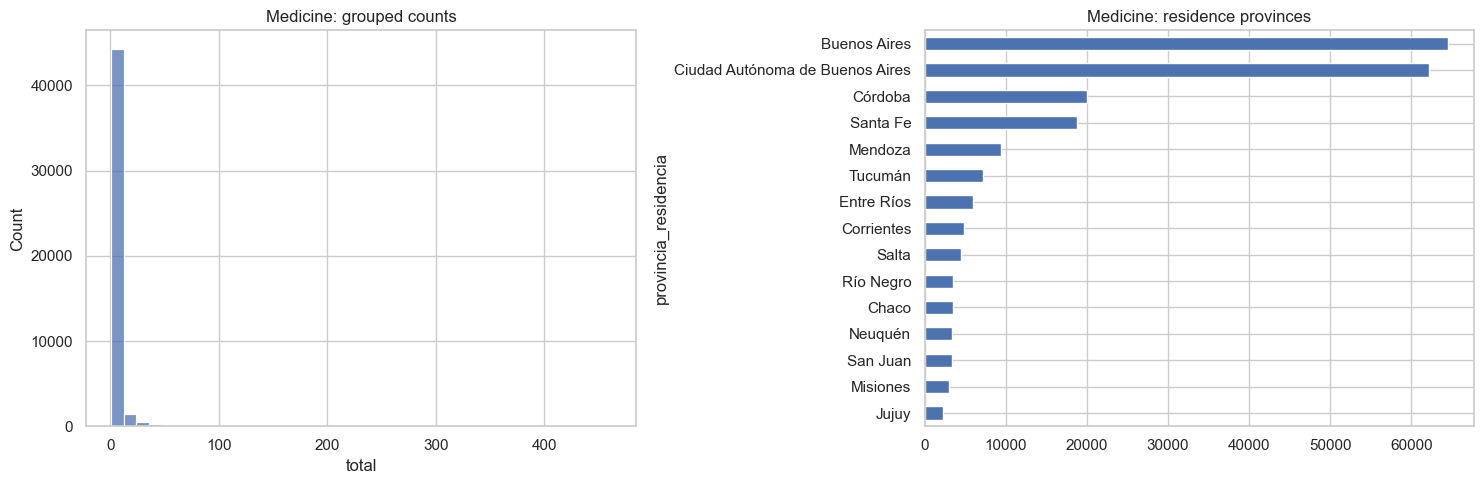

In [42]:
print("Professionals represented:",medicos["total"].sum()); display(medicos.groupby("sexo",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); display(medicos.groupby("grupo_etareo",dropna=False)["total"].sum().sort_index().to_frame("professionals")); display(medicos.groupby("provincia_residencia",dropna=False)["total"].sum().sort_values(ascending=False).head(15).to_frame("professionals")); display(medicos.groupby("pais_origen",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); fig,axes=plt.subplots(1,2,figsize=(15,5)); sns.histplot(data=medicos,x="total",bins=40,ax=axes[0]); axes[0].set_title("Medicine: grouped counts"); medicos.groupby("provincia_residencia")["total"].sum().sort_values(ascending=False).head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Medicine: residence provinces"); plt.tight_layout(); plt.show()

## 3. REFES establishments XLSX

In [43]:
refes_raw = pd.read_excel(ROOT / "establecimientos-asistenciales-asentados-registro-federal-refes-20260114 (1).xlsx", sheet_name=0, na_values=CSV_NA, dtype="string"); refes = refes_raw.copy(); refes["provincia_id"] = pd.to_numeric(refes["provincia_id"], errors="coerce").astype("Int64"); refes["departamento_id"] = pd.to_numeric(refes["departamento_id"], errors="coerce").astype("Int64"); refes["tipologia_id"] = pd.to_numeric(refes["tipologia_id"], errors="coerce").astype("Int64"); refes["longitud"] = pd.to_numeric(refes["longitud"], errors="coerce"); refes["latitud"] = pd.to_numeric(refes["latitud"], errors="coerce"); refes["coordinate_status"] = "missing_or_non_numeric"; coordinate_pair = refes["longitud"].notna() & refes["latitud"].notna(); in_argentina_bounds = refes["longitud"].between(-75, -50) & refes["latitud"].between(-56, -20); refes.loc[coordinate_pair & in_argentina_bounds, "coordinate_status"] = "valid_argentina_bounds"; refes.loc[coordinate_pair & ~in_argentina_bounds, "coordinate_status"] = "out_of_argentina_bounds"; print(refes.shape); display(refes.head()); display(refes.dtypes.to_frame("dtype")); display(refes["coordinate_status"].value_counts().to_frame("rows"))

(36074, 20)


,establecimiento_id,establecimiento_nombre,localidad_id,localidad_nombre,provincia_id,provincia_nombre,departamento_id,departamento_nombre,codloc,codent,origen_financiamiento,tipologia_id,tipologia_sigla,tipologia_nombre,cp,domicilio,sitio_web,longitud,latitud,coordinate_status
0,50500212361896,C.P.A. JALIFF ODONTOLOGIA.-,50021010001,GODOY CRUZ,50,MENDOZA,21,GODOY CRUZ,10,1,Privado,50,ESSIDT,Con atención médica diaria y con especialidade...,5501,JUAN B. JUSTO 1730,<NA>,-68.865833,-32.906847,valid_argentina_bounds
1,15060702322137,JUNTOS A LA PAR - APAND,6070010000,BARADERO,6,BUENOS AIRES,70,BARADERO,10,0,Privado,17,ESCIRES,Vivienda para personas mayores,2942,SANCHEZ DE LORIA Y LINO PIÑEIRO,<NA>,<NA>,<NA>,missing_or_non_numeric
2,10065602322140,CLINICA PRIVADA PASO DEL REY,6560010005,PASO DEL REY,6,BUENOS AIRES,560,MORENO,10,5,Privado,10,ESCIG,Bajo riesgo con internación simple,1742,Salvador María del Carril N°421,<NA>,-58.761396,-34.653411,valid_argentina_bounds
3,50500072161897,CENTRO DE PROMOCION DE LA SALUD Y MEDICINA DEP...,50007010009,9A. SECCION,50,MENDOZA,7,CAPITAL,10,9,Provincial,50,ESSIDT,Con atención médica diaria y con especialidade...,5500,AVENIDA DEL LIBERTADOR S/N ACONCAGUA ARENA,www.mendoza.gov.ar,-68.884033,-32.884661,valid_argentina_bounds
4,50500072361898,C.D.C. CENTRO MEDICO.-,50007010002,2A. SECCION,50,MENDOZA,7,CAPITAL,10,2,Privado,50,ESSIDT,Con atención médica diaria y con especialidade...,5500,PRIMITIVO DE LA RETA 672,www.clinicadecuyosa.org,-68.841902,-32.895553,valid_argentina_bounds


,dtype
establecimiento_id,string
establecimiento_nombre,string
localidad_id,string
localidad_nombre,string
provincia_id,Int64
provincia_nombre,string
departamento_id,Int64
departamento_nombre,string
codloc,string
codent,string


,rows
coordinate_status,
valid_argentina_bounds,28327
missing_or_non_numeric,7722
out_of_argentina_bounds,25


In [44]:
refes_missing=refes.isna().sum().to_frame("missing"); refes_missing["missing_pct"]=refes_missing["missing"]/len(refes)*100; display(refes_missing.sort_values("missing",ascending=False)); print("Duplicate rows:",refes.duplicated().sum()); print("Duplicate establishment IDs:",refes["establecimiento_id"].duplicated().sum()); display(refes.loc[refes["coordinate_status"] != "valid_argentina_bounds", ["establecimiento_id","provincia_nombre","longitud","latitud","coordinate_status"]].head(20)); refes_outliers=[]
for column in refes.select_dtypes(include="number").columns:
 values=refes[column].dropna(); q1,q3=values.quantile([.25,.75]); iqr=q3-q1; lower,upper=q1-1.5*iqr,q3+1.5*iqr; refes_outliers.append([column,q1,q3,lower,upper,int(((values<lower)|(values>upper)).sum())])
display(pd.DataFrame(refes_outliers,columns=["column","q1","q3","lower","upper","outlier_count"])); display(refes["origen_financiamiento"].value_counts(dropna=False).to_frame("establishments")); display(refes["provincia_nombre"].value_counts(dropna=False).head(15).to_frame("establishments")); display(refes["tipologia_sigla"].value_counts(dropna=False).head(20).to_frame("establishments"))

,missing,missing_pct
sitio_web,33251,92.174419
longitud,7722,21.405999
latitud,7722,21.405999
codent,674,1.868382
localidad_nombre,0,0.000000
localidad_id,0,0.000000
establecimiento_nombre,0,0.000000
establecimiento_id,0,0.000000
departamento_nombre,0,0.000000
provincia_id,0,0.000000


Duplicate rows: 0
Duplicate establishment IDs: 0


,establecimiento_id,provincia_nombre,longitud,latitud,coordinate_status
1,15060702322137,BUENOS AIRES,<NA>,<NA>,missing_or_non_numeric
8,50900702399770,TUCUMÁN,<NA>,<NA>,missing_or_non_numeric
9,50901052399816,TUCUMÁN,<NA>,<NA>,missing_or_non_numeric
10,50900842399821,TUCUMÁN,<NA>,<NA>,missing_or_non_numeric
12,50821192189246,SANTA FE,<NA>,<NA>,missing_or_non_numeric
16,53300842344025,ENTRE RÍOS,<NA>,<NA>,missing_or_non_numeric
17,51140562336517,CÓRDOBA,<NA>,<NA>,missing_or_non_numeric
19,52221402127615,CHACO,<NA>,<NA>,missing_or_non_numeric
21,50300702344029,ENTRE RÍOS,<NA>,<NA>,missing_or_non_numeric
22,50900842399935,TUCUMÁN,<NA>,<NA>,missing_or_non_numeric


,column,q1,q3,lower,upper,outlier_count
0,provincia_id,6.000000,58.000000,-72.000000,136.00000,0
1,departamento_id,21.000000,154.000000,-178.500000,353.50000,7258
2,tipologia_id,50.000000,51.000000,48.500000,52.50000,10604
3,longitud,-65.428866,-58.566252,-75.722788,-48.27233,18
4,latitud,-34.887608,-31.242885,-40.354693,-25.77580,3707


,establishments
origen_financiamiento,
Privado,23208
Provincial,6943
Municipal,4955
Seguridad Social,254
FFAA/Seguridad,168
Otros,154
Servicio Penitenciario Provincial,130
Universitario público,76
Mutual,75


,establishments
provincia_nombre,
BUENOS AIRES,10161
CÓRDOBA,4107
MENDOZA,2401
TUCUMÁN,1953
CABA,1914
SANTA FE,1691
NEUQUÉN,1581
CHUBUT,1302
ENTRE RÍOS,1212


,establishments
tipologia_sigla,
ESSIDT,17169
ESSID,4837
ESCL,4193
ESSIT,3464
ESCIRES,2637
ESCIG,2280
ESCIE,601
ESCIETE,427
ESCIESM,342


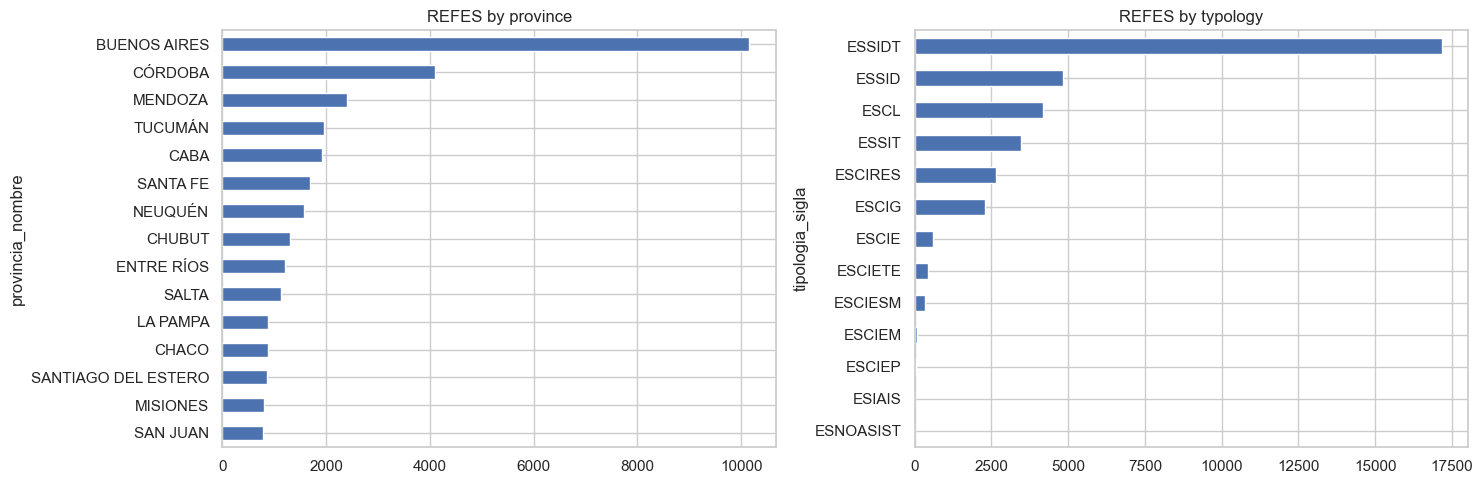

Valid-looking coordinates used in map: 28327 of 28352
REFES map CRS: EPSG:4326


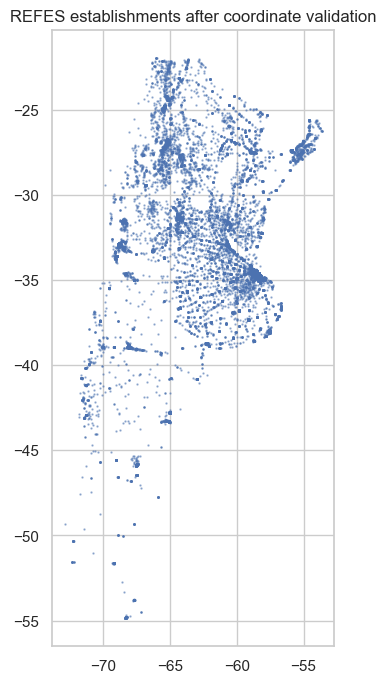

In [45]:
fig,axes=plt.subplots(1,2,figsize=(15,5)); refes["provincia_nombre"].value_counts().head(15).sort_values().plot.barh(ax=axes[0]); axes[0].set_title("REFES by province"); refes["tipologia_sigla"].value_counts().head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("REFES by typology"); plt.tight_layout(); plt.show(); refes_points=refes.loc[refes["coordinate_status"] == "valid_argentina_bounds"].copy(); print("Valid-looking coordinates used in map:",len(refes_points),"of",refes[["longitud","latitud"]].dropna().shape[0]); refes_map=gpd.GeoDataFrame(refes_points,geometry=gpd.points_from_xy(refes_points["longitud"],refes_points["latitud"]),crs="EPSG:4326"); print("REFES map CRS:",refes_map.crs); refes_map.plot(figsize=(8,8),markersize=0.5,alpha=0.5); plt.title("REFES establishments after coordinate validation"); plt.show()

## 4. BAHRA GeoJSON

In [46]:
bahra_all=gpd.read_file(ROOT / "base_total.geojson" / "base_total.geojson"); bahra_all_crs=bahra_all.to_crs("EPSG:4326") if bahra_all.crs is None else bahra_all.to_crs("EPSG:4326"); bahra_centroid_lat=bahra_all_crs.geometry.centroid.y; bahra=bahra_all_crs.loc[bahra_centroid_lat >= -60].copy(); print("BAHRA before Antarctica cut:",len(bahra_all_crs)); print("BAHRA removed south of 60°S:",len(bahra_all_crs)-len(bahra)); print("Shape after cut:",bahra.shape,"CRS:",bahra.crs); display(bahra.head()); display(bahra.dtypes.to_frame("dtype")); bahra_missing=bahra.drop(columns="geometry").isna().sum().to_frame("missing"); bahra_missing["missing_pct"]=bahra_missing["missing"]/len(bahra)*100; display(bahra_missing.sort_values("missing",ascending=False)); print("Empty geometries:",bahra.geometry.is_empty.sum(),"Invalid geometries:",(~bahra.geometry.is_valid).sum()); display(bahra["tipo"].value_counts(dropna=False).to_frame("settlements")); display(bahra.groupby(["nom_pcia","tipo"],dropna=False).size().unstack(fill_value=0).head(15))

BAHRA before Antarctica cut: 14673
BAHRA removed south of 60°S: 13
Shape after cut: (14660, 18) CRS: EPSG:4326


C:\Users\anapa\AppData\Local\Temp\ipykernel_8796\3214993921.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bahra_all=gpd.read_file(ROOT / "base_total.geojson" / "base_total.geojson"); bahra_all_crs=bahra_all.to_crs("EPSG:4326") if bahra_all.crs is None else bahra_all.to_crs("EPSG:4326"); bahra_centroid_lat=bahra_all_crs.geometry.centroid.y; bahra=bahra_all_crs.loc[bahra_centroid_lat >= -60].copy(); print("BAHRA before Antarctica cut:",len(bahra_all_crs)); print("BAHRA removed south of 60°S:",len(bahra_all_crs)-len(bahra)); print("Shape after cut:",bahra.shape,"CRS:",bahra.crs); display(bahra.head()); display(bahra.dtypes.to_frame("dtype")); bahra_missing=bahra.drop(columns="geometry").isna().sum().to_frame("missing"); bahra_missing["missing_pct"]=bahra_missing["missing"]/len(bahra)*100; display(bahra_missing.sort_values("missing",ascending=Fa

,id,cod_pcia,nom_pcia,cod_depto,nom_depto,cod_ase,nombre,tipo,cod_aglo,nom_aglo,cod_agl,nom_agl,lat_gd,long_gd,lat_gs,long_gs,fuente,geometry
0,780.0,06,Buenos Aires,06021,Alberti,06021A06,Palantelén,Paraje,NaN,NaN,060021,Alberti,-35.167391,-60.334732,"-35º10' 3""","-60º20' 5""",INDEC. ACA,MULTIPOINT (-60.33473 -35.16739)
1,851.0,06,Buenos Aires,06049,Azul,06049A30,Vicente Pereda,Paraje,NaN,NaN,060049,Azul,-36.698608,-59.782276,"-36º41'55""","-59º46'56""",INDEC. ACA,MULTIPOINT (-59.78228 -36.69861)
2,446.0,14,Córdoba,14014,Capital,1401401002,La Floresta,Entidad,0002,Gran Córdoba,140077,Córdoba,-31.396847,-64.059869,"-31º23'49""","-64º 3'36""",INDEC,MULTIPOINT (-64.05987 -31.39685)
3,572.0,50,Mendoza,50028,Guaymallén,5002802001,Bermejo,Entidad,0004,Gran Mendoza,500028,Guaymallén,-32.867313,-68.779540,"-32º52' 2""","-68º46'46""",INDEC,MULTIPOINT (-68.77954 -32.86731)
4,1324.0,06,Buenos Aires,06231,Daireaux,06231A09,Luro,Paraje,NaN,NaN,060231,Daireaux,-36.650001,-62.117106,"-36º39' 0""","-62º 7' 2""",IGN. SIG 250,MULTIPOINT (-62.11711 -36.65)


,dtype
id,float64
cod_pcia,str
nom_pcia,str
cod_depto,str
nom_depto,str
cod_ase,str
nombre,str
tipo,str
cod_aglo,str
nom_aglo,str


,missing,missing_pct
nom_aglo,10431,71.152797
cod_aglo,10426,71.118690
long_gs,1,0.006821
nom_depto,1,0.006821
id,0,0.000000
cod_depto,0,0.000000
cod_ase,0,0.000000
nom_pcia,0,0.000000
cod_pcia,0,0.000000
tipo,0,0.000000


Empty geometries: 0 Invalid geometries: 0


,settlements
tipo,
Paraje,10425
Localidad simple,3255
Entidad,707
Componente de localidad compuesta,273


tipo,Componente de localidad compuesta,Entidad,Localidad simple,Paraje
nom_pcia,,,,
Buenos Aires,53,350,540,1414
Catamarca,9,38,145,325
Chaco,6,0,85,704
Chubut,0,22,68,202
Ciudad de Buenos Aires,1,48,0,0
Corrientes,1,0,76,551
Córdoba,71,43,452,950
Entre Ríos,7,14,162,488
Formosa,0,2,62,359


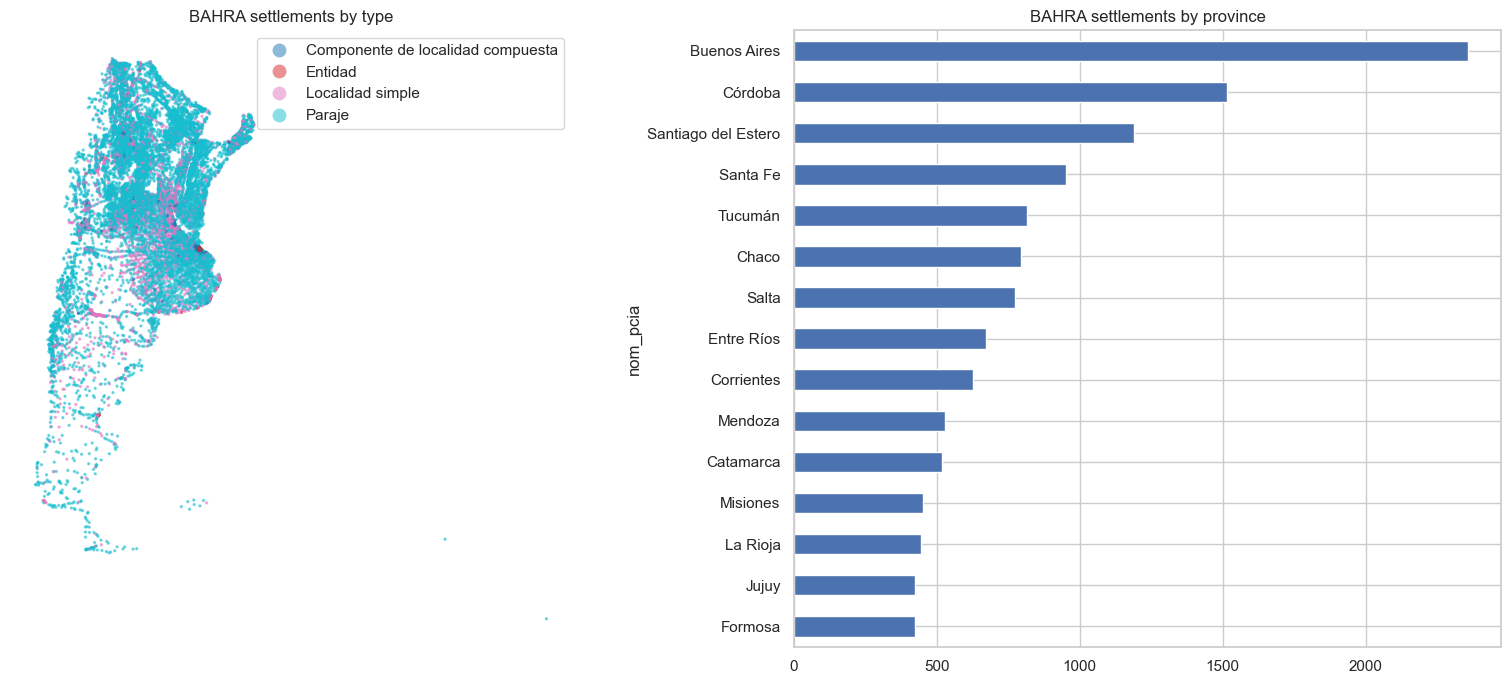

In [47]:
fig,axes=plt.subplots(1,2,figsize=(16,7)); bahra.plot(ax=axes[0],column="tipo",markersize=2,alpha=.5,legend=True); axes[0].set_title("BAHRA settlements by type"); axes[0].set_axis_off(); bahra["nom_pcia"].value_counts().head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("BAHRA settlements by province"); plt.tight_layout(); plt.show()

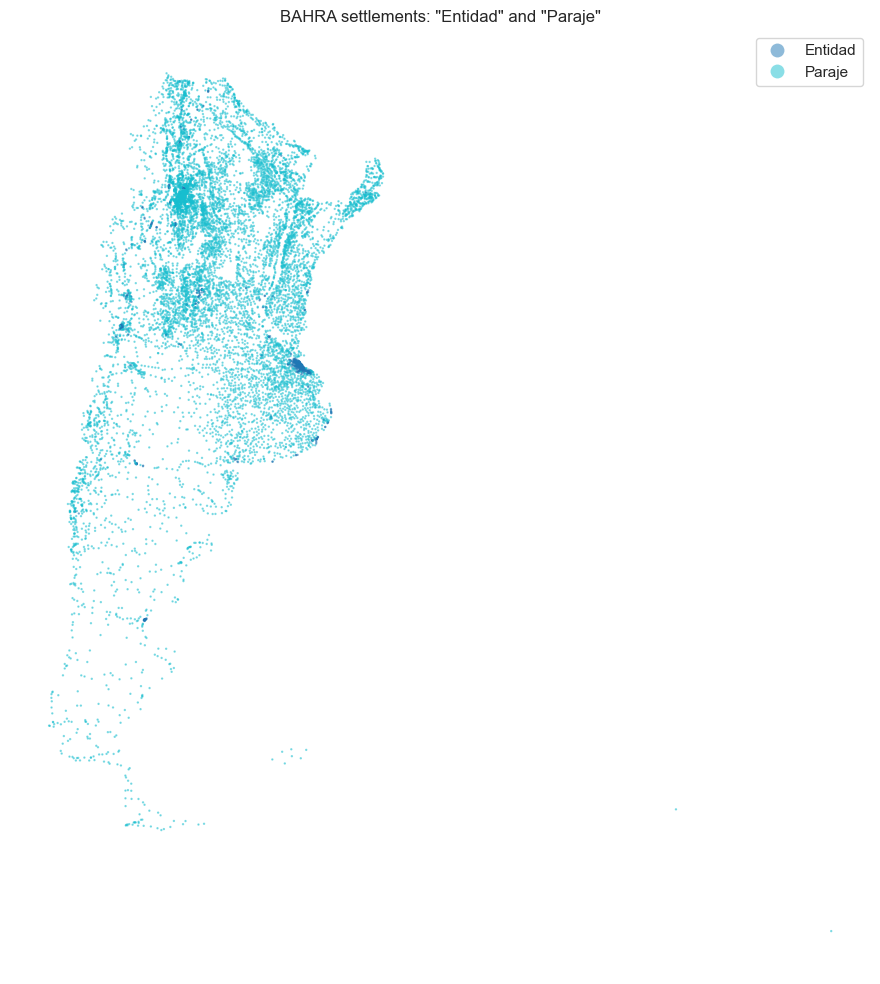

In [48]:
bahra_selected = bahra[bahra["tipo"].isin(["Entidad", "Paraje"])].copy()

ax = bahra_selected.plot(
    figsize=(10, 10),
    column="tipo",
    categorical=True,
    legend=True,
    markersize=0.5,
    alpha=0.5,
)

ax.set_title('BAHRA settlements: "Entidad" and "Paraje"')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Census radios Shapefile

In [49]:
radios_raw=gpd.read_file(ROOT / "radios_censales2" / "radios_censales2.shp",encoding="cp1252"); print("Shape:",radios_raw.shape); print("CRS read from .prj:",radios_raw.crs); print("CRS documented in metadatos_radios_censales.pdf: EPSG:4326"); print("Raw bounds:",radios_raw.total_bounds); radios_all=radios_raw.to_crs("EPSG:4326"); print("CRS after correction:",radios_all.crs); print("Corrected longitude/latitude bounds before Antarctica cut:",radios_all.total_bounds); radios_centroid_lat=radios_all.to_crs("EPSG:3857").centroid.to_crs("EPSG:4326").y; radios=radios_all.loc[radios_centroid_lat >= -60].copy(); print("Census radios before Antarctica cut:",len(radios_all)); print("Census radios removed south of 60°S:",len(radios_all)-len(radios)); print("Corrected longitude/latitude bounds after cut:",radios.total_bounds); display(radios.head()); display(radios.dtypes.to_frame("dtype")); radios_missing=radios.drop(columns="geometry").isna().sum().to_frame("missing"); radios_missing["missing_pct"]=radios_missing["missing"]/len(radios)*100; display(radios_missing.sort_values("missing",ascending=False)); print("Duplicate radio IDs:",radios["id"].duplicated().sum()); print("Empty geometries:",radios.geometry.is_empty.sum(),"Invalid geometries:",(~radios.geometry.is_valid).sum()); display(radios["tro"].value_counts(dropna=False).to_frame("radios")); display(radios.groupby(["jur","tro"],dropna=False).size().unstack(fill_value=0).head(15))

c:\Users\anapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: radios_censales2\radios_censales2.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Shape: (66515, 12)
CRS read from .prj: EPSG:3857
CRS documented in metadatos_radios_censales.pdf: EPSG:4326
Raw bounds: [ -8237642.3187022  -37718348.65140086  -2782987.26983189
  -2485234.61756082]
CRS after correction: EPSG:4326
Corrected longitude/latitude bounds before Antarctica cut: [-74.         -89.69035289 -25.         -21.78085593]
Census radios before Antarctica cut: 66515
Census radios removed south of 60°S: 1
Corrected longitude/latitude bounds after cut: [-73.56658852 -59.46319341 -26.25206971 -21.78085593]


,fid,id,cpr,jur,cde,dpto,cfn,cro,tro,cod_indec,sag,geometry
0,63497,87915.0,58,Neuquén,58035,Confluencia,11,12,U,580351112,INDEC,"POLYGON ((-68.08451 -38.97923, -68.08372 -38.9..."
1,63498,87914.0,58,Neuquén,58035,Confluencia,11,11,U,580351111,INDEC,"POLYGON ((-68.07345 -38.98177, -68.07345 -38.9..."
2,63499,73751.0,06,Buenos Aires,06035,Avellaneda,14,10,U,060351410,INDEC,"POLYGON ((-58.35159 -34.67282, -58.35299 -34.6..."
3,63500,87916.0,58,Neuquén,58035,Confluencia,11,13,U,580351113,INDEC,"POLYGON ((-68.08458 -38.99227, -68.08485 -38.9..."
4,63501,39772.0,22,Chaco,22140,San Fernando,12,06,U,221401206,INDEC,"POLYGON ((-58.99172 -27.45263, -58.99086 -27.4..."


,dtype
fid,int32
id,float64
cpr,str
jur,str
cde,str
dpto,str
cfn,str
cro,str
tro,str
cod_indec,str


,missing,missing_pct
tro,26,0.03909
id,0,0.00000
fid,0,0.00000
cpr,0,0.00000
jur,0,0.00000
dpto,0,0.00000
cde,0,0.00000
cfn,0,0.00000
cro,0,0.00000
cod_indec,0,0.00000


Duplicate radio IDs: 0
Empty geometries: 0 Invalid geometries: 3


,radios
tro,
U,54459
R,9346
M,2683
NaN,26


tro,M,R,U,NaN
jur,,,,
Buenos Aires,0,3230,20671,0
Catamarca,66,163,464,0
Chaco,70,470,1407,0
Chubut,32,138,858,0
Ciudad Autónoma de Buenos Aires,0,0,3820,0
Corrientes,139,674,1172,0
Córdoba,512,493,5715,0
Entre Ríos,176,1078,1959,11
Formosa,81,198,702,0


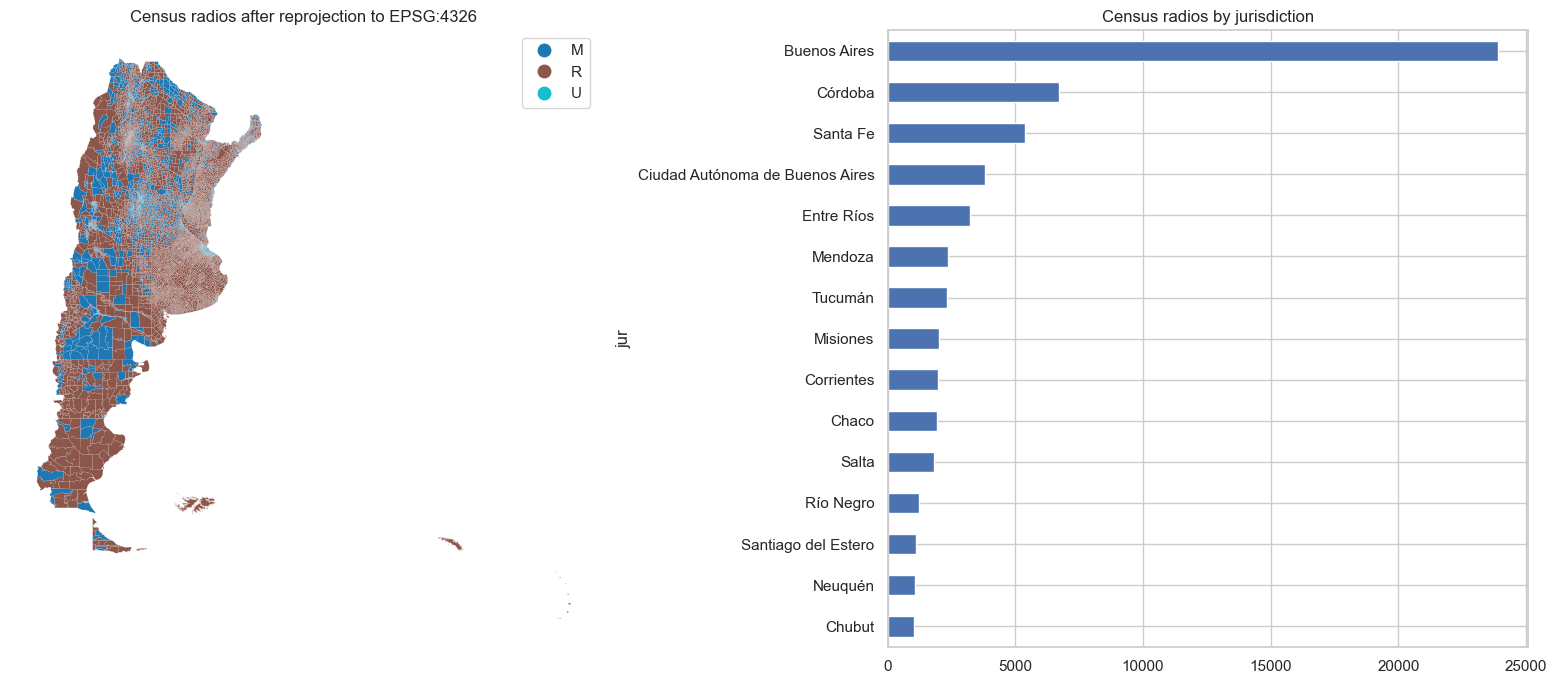

In [50]:
fig,axes=plt.subplots(1,2,figsize=(16,7)); radios.plot(ax=axes[0],column="tro",legend=True,linewidth=.05); axes[0].set_title("Census radios after reprojection to EPSG:4326"); axes[0].set_axis_off(); radios["jur"].value_counts().head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Census radios by jurisdiction"); plt.tight_layout(); plt.show()

The objects `enfermeria`, `medicos`, `refes`, `refes_missing_coordinates`, `refes_map`, `bahra_all`, filtered `bahra`, `radios_raw`, `radios_all`, and filtered `radios` remain available. REFES rows are retained with an auditable `coordinate_status`; records needing recovery are normalized into separate search fields without changing their official values. Healthsites is configured through `HEALTHSITES_API_KEY`, and no bulk request is sent until the key is present and the endpoint response has been inspected. BAHRA and census radios are filtered to centroid latitude >= -60°S.


# 6. Limpieza REFES

## Prepare REFES records for Healthsites matching

This section keeps the original REFES fields and creates separate normalized search fields. It does not overwrite official names or addresses. The normalization is designed for matching against Healthsites/OSM names and addresses.

In [51]:
refes_missing_coordinates = refes[
    refes["coordinate_status"] != "valid_argentina_bounds"
].copy()

print("Records requiring coordinate recovery:", len(refes_missing_coordinates))
display(refes_missing_coordinates[
    ["establecimiento_id", "establecimiento_nombre", "localidad_nombre",
     "provincia_nombre", "domicilio", "tipologia_sigla", "longitud",
     "latitud", "coordinate_status"]
].head(20))
display(refes_missing_coordinates["coordinate_status"].value_counts().to_frame("records"))


Records requiring coordinate recovery: 7747


,establecimiento_id,establecimiento_nombre,localidad_nombre,provincia_nombre,domicilio,tipologia_sigla,longitud,latitud,coordinate_status
1,15060702322137,JUNTOS A LA PAR - APAND,BARADERO,BUENOS AIRES,SANCHEZ DE LORIA Y LINO PIÑEIRO,ESCIRES,<NA>,<NA>,missing_or_non_numeric
8,50900702399770,CONSULTORIO CARDIOLOGICO,MONTEROS,TUCUMÁN,calle San Martin N° 220,ESSIDT,<NA>,<NA>,missing_or_non_numeric
9,50901052399816,CONSULTORIO DE PSICOLOGIA NIETO BARTHABURU,TAFI VIEJO,TUCUMÁN,Calle Congreso N° 92,ESSIDT,<NA>,<NA>,missing_or_non_numeric
10,50900842399821,CONSULTORIO DE NUTRICION-VIGLIANO,SAN MIGUEL DE TUCUMAN,TUCUMÁN,Congreso N°693,ESSIDT,<NA>,<NA>,missing_or_non_numeric
12,50821192189246,CAPS DE BARRIO TIERRA DE SUEÑOS 3,ROLDAN,SANTA FE,SECTOR B - MANZANA 45 LOTE 1233,ESSIDT,<NA>,<NA>,missing_or_non_numeric
16,53300842344025,CENTAURI S.R.L.,PARANA,ENTRE RÍOS,9 DE JULIO N° 319,ESCL,<NA>,<NA>,missing_or_non_numeric
17,51140562336517,LABORATORIO DE ANALISIS CLINICOS DRA. BARILE,LA CARLOTA,CÓRDOBA,Sarmiento 1070,ESSID,<NA>,<NA>,missing_or_non_numeric
19,52221402127615,HOSPITAL DE DIA CON ALAS - SERVICIO DE SALUD ...,RESISTENCIA,CHACO,AV. 9 DE JULIO 1100 (PREDIO HOSPITAL DR. JULIO...,ESSIT,<NA>,<NA>,missing_or_non_numeric
21,50300702344029,CENTRO INTEGRAL DE REHABILITACION,LA PAZ,ENTRE RÍOS,3 DE FEBRERO N° 714,ESSIDT,<NA>,<NA>,missing_or_non_numeric
22,50900842399935,CONSULTORIO DE PSICOLOGIA MURATORE,SAN MIGUEL DE TUCUMAN,TUCUMÁN,Bolivar 440 Primero F,ESSIDT,<NA>,<NA>,missing_or_non_numeric


,records
coordinate_status,
missing_or_non_numeric,7722
out_of_argentina_bounds,25


In [52]:
refes_missing_coordinates["search_name"] = (
    refes_missing_coordinates["establecimiento_nombre"]
    .fillna("")
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
refes_missing_coordinates["search_address"] = (
    refes_missing_coordinates["domicilio"]
    .fillna("")
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"\bN[°ºO]?\b|\bNRO\b|\bNUMERO\b", " ", regex=True)
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
refes_missing_coordinates["search_locality"] = (
    refes_missing_coordinates["localidad_nombre"]
    .fillna("")
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
refes_missing_coordinates["search_province"] = (
    refes_missing_coordinates["provincia_nombre"]
    .fillna("")
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
refes_missing_coordinates["healthsites_query"] = (
    refes_missing_coordinates["search_name"] + ", " +
    refes_missing_coordinates["search_address"] + ", " +
    refes_missing_coordinates["search_locality"] + ", " +
    refes_missing_coordinates["search_province"] + ", Argentina"
).str.replace(r"(?:, )+", ", ", regex=True).str.strip(" ,")
display(refes_missing_coordinates[["establecimiento_id", "search_name", "search_address", "search_locality", "search_province", "healthsites_query"]].head(10))


,establecimiento_id,search_name,search_address,search_locality,search_province,healthsites_query
1,15060702322137,JUNTOS A LA PAR APAND,SANCHEZ DE LORIA Y LINO PINEIRO,BARADERO,BUENOS AIRES,"JUNTOS A LA PAR APAND, SANCHEZ DE LORIA Y LINO..."
8,50900702399770,CONSULTORIO CARDIOLOGICO,CALLE SAN MARTIN 220,MONTEROS,TUCUMAN,"CONSULTORIO CARDIOLOGICO, CALLE SAN MARTIN 220..."
9,50901052399816,CONSULTORIO DE PSICOLOGIA NIETO BARTHABURU,CALLE CONGRESO 92,TAFI VIEJO,TUCUMAN,"CONSULTORIO DE PSICOLOGIA NIETO BARTHABURU, CA..."
10,50900842399821,CONSULTORIO DE NUTRICION VIGLIANO,CONGRESO N693,SAN MIGUEL DE TUCUMAN,TUCUMAN,"CONSULTORIO DE NUTRICION VIGLIANO, CONGRESO N6..."
12,50821192189246,CAPS DE BARRIO TIERRA DE SUENOS 3,SECTOR B MANZANA 45 LOTE 1233,ROLDAN,SANTA FE,"CAPS DE BARRIO TIERRA DE SUENOS 3, SECTOR B MA..."
16,53300842344025,CENTAURI S R L,9 DE JULIO 319,PARANA,ENTRE RIOS,"CENTAURI S R L, 9 DE JULIO 319, PARANA, ENTRE ..."
17,51140562336517,LABORATORIO DE ANALISIS CLINICOS DRA BARILE,SARMIENTO 1070,LA CARLOTA,CORDOBA,"LABORATORIO DE ANALISIS CLINICOS DRA BARILE, S..."
19,52221402127615,HOSPITAL DE DIA CON ALAS SERVICIO DE SALUD MENTAL,AV 9 DE JULIO 1100 PREDIO HOSPITAL DR JULIO C ...,RESISTENCIA,CHACO,HOSPITAL DE DIA CON ALAS SERVICIO DE SALUD MEN...
21,50300702344029,CENTRO INTEGRAL DE REHABILITACION,3 DE FEBRERO 714,LA PAZ,ENTRE RIOS,"CENTRO INTEGRAL DE REHABILITACION, 3 DE FEBRER..."
22,50900842399935,CONSULTORIO DE PSICOLOGIA MURATORE,BOLIVAR 440 PRIMERO F,SAN MIGUEL DE TUCUMAN,TUCUMAN,"CONSULTORIO DE PSICOLOGIA MURATORE, BOLIVAR 44..."


## Healthsites API connection

The API key is read from the `HEALTHSITES_API_KEY` environment variable and is never stored in the notebook. The connection is configured but no bulk search is launched automatically. Healthsites records are facility records; the next step is to test the documented facilities endpoint and inspect its response schema before writing matching logic.

In [ ]:
import os
import requests
from dotenv import load_dotenv


load_dotenv()

HEALTHSITES_API_KEY = os.getenv("HEALTHSITES_API_KEY")
HEALTHSITES_API_URL = "https://healthsites.io/api/v3/facilities/"

# Define search parameters
country_filter = "Argentina"  # Adjust to your target country name
page_number = 1               # Adjust for pagination

healthsites_session = requests.Session()
healthsites_session.headers.update({
    "User-Agent": "radio-eda/0.1 (research project; contact repository owner)",
    "Accept": "application/json",
})

# Include country and page in the request parameters
healthsites_request_params = {
    "api-key": HEALTHSITES_API_KEY,
    "country": country_filter,
    "page": page_number,
} if HEALTHSITES_API_KEY else {}

print("Healthsites endpoint:", HEALTHSITES_API_URL)
print("API key configured:", bool(HEALTHSITES_API_KEY))
print(f"Query filters -> Country: '{country_filter}', Page: {page_number}")

if not HEALTHSITES_API_KEY:
    print("Set HEALTHS_API_KEY before making API requests; no request was sent.")
else:
    healthsites_connection_response = healthsites_session.get(
        HEALTHSITES_API_URL, params=healthsites_request_params, timeout=30
    )
    print("HTTP status:", healthsites_connection_response.status_code)
    print("Response content type:", healthsites_connection_response.headers.get("content-type"))
    
    if healthsites_connection_response.status_code == 403:
         print("Access forbidden. Server response body:")
         print(healthsites_connection_response.text)
         
    healthsites_connection_response.raise_for_status()
    healthsites_preview = healthsites_connection_response.json()
    print("Response type:", type(healthsites_preview).__name__)
    display(healthsites_preview if isinstance(healthsites_preview, dict) else healthsites_preview[:2])

Healthsites endpoint: https://healthsites.io/api/v3/facilities/
API key configured: True
Query filters -> Country: 'Argentina', Page: 1
HTTP status: 200
Response content type: application/json
Response type: list


[{'attributes': {'amenity': 'clinic',
   'name': 'Kronos - Centro Médico de Alto Rendimiento',
   'opening_hours': 'Mo-Fr 09:00-21:00',
   'addr_housenumber': '264 (O)',
   'addr_street': 'Santa Fe',
   'addr_postcode': 'J5402ACF',
   'addr_city': 'San Juan',
   'changeset_id': 162772516.0,
   'changeset_version': 3.0,
   'changeset_timestamp': '2025-02-21T09:54:02Z',
   'changeset_user': 'guillemmal',
   'uuid': 'a9aa6684d8764f599bcdcf39740eaba4'},
  'centroid': {'type': 'Point',
   'coordinates': [-68.52935711089329, -31.53941071819466]},
  'osm_id': 8909856839,
  'osm_type': 'node',
  'completeness': 25.0},
 {'attributes': {'amenity': 'clinic',
   'name': 'SMI Emergencias',
   'addr_housenumber': '259 (O)',
   'addr_street': 'Avenida Córdoba',
   'addr_postcode': 'J5402AEC',
   'addr_city': 'San Juan',
   'changeset_id': 162772516.0,
   'changeset_version': 3.0,
   'changeset_timestamp': '2025-02-21T09:54:02Z',
   'changeset_user': 'guillemmal',
   'uuid': '3a72dd2d99b8425793f933ade

## Healthsites base

In [ ]:
import os
import time
import requests
import pandas as pd
from pathlib import Path

HEALTHSITES_API_KEY = os.getenv("HEALTHSITES_API_KEY", "").strip("'\"")
HEALTHSITES_API_URL = "https://healthsites.io/api/v3/facilities/"

# Cache folder to save pages locally as JSON so you never re-download them
cache_dir = Path("healthsites_cache")
cache_dir.mkdir(exist_ok=True)

def fetch_and_cache_argentina(api_key, start_page=1, max_page=120):
    headers = {
        "User-Agent": "radio-eda/0.1 (research project)",
        "Accept": "application/json",
    }
    
    all_facilities = []
    
    for page in range(start_page, max_page + 1):
        cache_file = cache_dir / f"argentina_page_{page}.json"
        
        # Check if page is already cached locally
        if cache_file.exists():
            print(f"Loading page {page} from local cache...")
            data = pd.read_json(cache_file, typ='series').to_dict() # or load via json module
            import json
            with open(cache_file, "r", encoding="utf-8") as f:
                data = json.load(f)
        else:
            print(f"Fetching page {page} from Healthsites API...")
            params = {"api-key": api_key, "country": "Argentina", "page": page}
            response = requests.get(HEALTHSITES_API_URL, headers=headers, params=params, timeout=30)
            
            if response.status_code == 403:
                print(f"Hit rate limit or 403 Forbidden on page {page}. Stopping here for now.")
                break
            elif response.status_code != 200:
                print(f"Error status {response.status_code} on page {page}")
                break
                
            data = response.json()
            
            # Save raw page locally to cache
            import json
            with open(cache_file, "w", encoding="utf-8") as f:
                json.dump(data, f)
                
            # Be polite to the server: sleep 1 second between live requests
            time.sleep(1)
            
        results = data.get("results", []) if isinstance(data, dict) else data
        if not results:
            print("Reached end of available pages.")
            break
            
        # Filter out pharmacies on the fly
        for facility in results:
            f_type = str(facility.get("facility_type", "")).lower()
            amenity = str(facility.get("amenity", "")).lower()
            name = str(facility.get("name", "")).lower()
            
            is_pharmacy = any(word in f_type or word in amenity or word in name for word in ["pharmacy", "farmacia"])
            if not is_pharmacy:
                all_facilities.append(facility)
                
        # Stop if API indicates no next page
        if isinstance(data, dict) and not data.get("next"):
            break
            
    return pd.DataFrame(all_facilities)


hs_df = fetch_and_cache_argentina(HEALTHSITES_API_KEY)

Fetching page 1 from Healthsites API...
Fetching page 2 from Healthsites API...
Fetching page 3 from Healthsites API...
Fetching page 4 from Healthsites API...
Fetching page 5 from Healthsites API...
Fetching page 6 from Healthsites API...
Fetching page 7 from Healthsites API...
Fetching page 8 from Healthsites API...
Fetching page 9 from Healthsites API...
Fetching page 10 from Healthsites API...
Fetching page 11 from Healthsites API...
Fetching page 12 from Healthsites API...
Fetching page 13 from Healthsites API...
Fetching page 14 from Healthsites API...
Fetching page 15 from Healthsites API...
Fetching page 16 from Healthsites API...
Fetching page 17 from Healthsites API...
Fetching page 18 from Healthsites API...
Fetching page 19 from Healthsites API...
Fetching page 20 from Healthsites API...
Fetching page 21 from Healthsites API...
Fetching page 22 from Healthsites API...
Fetching page 23 from Healthsites API...
Fetching page 24 from Healthsites API...
Fetching page 25 from Hea

In [76]:
hs_df = fetch_and_cache_argentina(HEALTHSITES_API_KEY)

Loading page 1 from local cache...
Loading page 2 from local cache...
Loading page 3 from local cache...
Loading page 4 from local cache...
Loading page 5 from local cache...
Loading page 6 from local cache...
Loading page 7 from local cache...
Loading page 8 from local cache...
Loading page 9 from local cache...
Loading page 10 from local cache...
Loading page 11 from local cache...
Loading page 12 from local cache...
Loading page 13 from local cache...
Loading page 14 from local cache...
Loading page 15 from local cache...
Loading page 16 from local cache...
Loading page 17 from local cache...
Loading page 18 from local cache...
Loading page 19 from local cache...
Loading page 20 from local cache...
Loading page 21 from local cache...
Loading page 22 from local cache...
Loading page 23 from local cache...
Loading page 24 from local cache...
Loading page 25 from local cache...
Loading page 26 from local cache...
Loading page 27 from local cache...
Loading page 28 from local cache...
L

In [77]:
hs_df

,attributes,centroid,osm_id,osm_type,completeness
0,"{'amenity': 'clinic', 'name': 'Kronos - Centro...","{'type': 'Point', 'coordinates': [-68.52935711...",8909856839,node,25.000
1,"{'amenity': 'clinic', 'name': 'SMI Emergencias...","{'type': 'Point', 'coordinates': [-68.52914161...",8909856824,node,21.875
2,"{'amenity': 'pharmacy', 'name': 'Farmacia Sarm...","{'type': 'Point', 'coordinates': [-68.52976681...",7943375686,node,21.875
3,"{'amenity': 'clinic', 'name': 'Ethical Centro ...","{'type': 'Point', 'coordinates': [-68.52919684...",7943375088,node,21.875
4,"{'healthcare': 'alternative', 'name': 'Dharma'...","{'type': 'Point', 'coordinates': [-60.63049580...",12606853538,node,9.375
...,...,...,...,...,...
11995,"{'amenity': 'pharmacy', 'healthcare': 'pharmac...","{'type': 'Point', 'coordinates': [-64.57616373...",1088091783,node,12.500
11996,"{'amenity': 'doctors', 'healthcare': 'doctor',...","{'type': 'Point', 'coordinates': [-68.87707181...",8041424785,node,12.500
11997,"{'amenity': 'dentist', 'healthcare': 'dentist'...","{'type': 'Point', 'coordinates': [-58.78657258...",8043211006,node,12.500
11998,"{'amenity': 'doctors', 'healthcare': 'doctor',...","{'type': 'Point', 'coordinates': [-64.52661596...",8044777976,node,12.500


### Field normalization

In [78]:
import pandas as pd
import unicodedata

# 1. Expand the 'attributes' dictionary column into separate columns
# Using .tolist() is much faster than .apply(pd.Series) for 12,000 rows
attributes_df = pd.DataFrame(hs_df["attributes"].tolist(), index=hs_df.index)
hs_df = pd.concat([hs_df, attributes_df], axis=1)

In [79]:


# Ensure all target columns exist (in case none of the 12,000 dicts had a specific key)
for col in ['name', 'addr_street', 'addr_housenumber', 'addr_city', 'addr_postcode', 'addr_province', 'addr_state']:
    if col not in hs_df.columns:
        hs_df[col] = ""

# 2. Normalize search_name
hs_df["search_name"] = (
    hs_df["name"]
    .fillna("")
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 3. Normalize search_address (Combining street and housenumber)
hs_df["raw_address"] = hs_df["addr_street"].fillna("") + " " + hs_df["addr_housenumber"].fillna("")
hs_df["search_address"] = (
    hs_df["raw_address"]
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"\bN[°ºO]?\b|\bNRO\b|\bNUMERO\b", " ", regex=True)
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(r"\s+\b(O|E|S|N|OESTE|ESTE|SUR|NORTE)\b$", "", regex=True)
)

# 4. Normalize search_locality
hs_df["search_locality"] = (
    hs_df["addr_city"]
    .fillna("")
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 5. Normalize search_province (Combining province and state as OSM uses both)
hs_df["raw_province"] = hs_df["addr_province"].fillna("") + hs_df["addr_state"].fillna("")
hs_df["search_province"] = (
    hs_df["raw_province"]
    .astype("string")
    .map(lambda value: unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("ascii"))
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 6. Extract numbers from postcode (e.g., 'J5402ACF' -> '5402')
hs_df["search_postcode"] = (
    hs_df["addr_postcode"]
    .fillna("")
    .astype("string")
    .str.extract(r'(\d+)', expand=False)
    .fillna("")
)

# 7. Create the final query string
hs_df["healthsites_query"] = (
    hs_df["search_name"] + ", " +
    hs_df["search_address"] + ", " +
    hs_df["search_locality"] + ", " +
    hs_df["search_province"] + ", ARGENTINA"
).str.replace(r"(?:, )+", ", ", regex=True).str.strip(" ,")

# Drop the temporary columns
hs_df = hs_df.drop(columns=["raw_address", "raw_province"])

# Verify results
display(hs_df[["osm_id", "search_name", "search_address", "search_locality", "search_postcode", "healthsites_query"]].head(10))

,osm_id,search_name,search_address,search_locality,search_postcode,healthsites_query
0,8909856839,KRONOS CENTRO MEDICO DE ALTO RENDIMIENTO,SANTA FE 264,SAN JUAN,5402,"KRONOS CENTRO MEDICO DE ALTO RENDIMIENTO, SANT..."
1,8909856824,SMI EMERGENCIAS,AVENIDA CORDOBA 259,SAN JUAN,5402,"SMI EMERGENCIAS, AVENIDA CORDOBA 259, SAN JUAN..."
2,7943375686,FARMACIA SARMIENTO,CATAMARCA 402,SAN JUAN,5402,"FARMACIA SARMIENTO, CATAMARCA 402, SAN JUAN, A..."
3,7943375088,ETHICAL CENTRO MEDICO,SANTA FE 254,SAN JUAN,5402,"ETHICAL CENTRO MEDICO, SANTA FE 254, SAN JUAN,..."
4,12606853538,DHARMA,,,,"DHARMA, ARGENTINA"
5,1667547333,SALA 1ROS AUXILIOS,,,,"SALA 1ROS AUXILIOS, ARGENTINA"
6,8909827358,INSTITUTO MEDICO,CATAMARCA 457,J5402GSI,5402,"INSTITUTO MEDICO, CATAMARCA 457, J5402GSI, ARG..."
7,8909827373,CIMYN,CATAMARCA 417,J5402GSI,5402,"CIMYN, CATAMARCA 417, J5402GSI, ARGENTINA"
8,544689993,SOLARI,,,,"SOLARI, ARGENTINA"
9,2358066357,BONACCI,AVENIDA PEDRO DE CASTRO BARROS 5207,,2011,"BONACCI, AVENIDA PEDRO DE CASTRO BARROS 5207, ..."


In [80]:
display(hs_df[["osm_id", "search_name", "search_address", "search_locality", "search_postcode", "healthsites_query"]].head(20))

,osm_id,search_name,search_address,search_locality,search_postcode,healthsites_query
0,8909856839,KRONOS CENTRO MEDICO DE ALTO RENDIMIENTO,SANTA FE 264,SAN JUAN,5402,"KRONOS CENTRO MEDICO DE ALTO RENDIMIENTO, SANT..."
1,8909856824,SMI EMERGENCIAS,AVENIDA CORDOBA 259,SAN JUAN,5402,"SMI EMERGENCIAS, AVENIDA CORDOBA 259, SAN JUAN..."
2,7943375686,FARMACIA SARMIENTO,CATAMARCA 402,SAN JUAN,5402,"FARMACIA SARMIENTO, CATAMARCA 402, SAN JUAN, A..."
3,7943375088,ETHICAL CENTRO MEDICO,SANTA FE 254,SAN JUAN,5402,"ETHICAL CENTRO MEDICO, SANTA FE 254, SAN JUAN,..."
4,12606853538,DHARMA,,,,"DHARMA, ARGENTINA"
5,1667547333,SALA 1ROS AUXILIOS,,,,"SALA 1ROS AUXILIOS, ARGENTINA"
6,8909827358,INSTITUTO MEDICO,CATAMARCA 457,J5402GSI,5402,"INSTITUTO MEDICO, CATAMARCA 457, J5402GSI, ARG..."
7,8909827373,CIMYN,CATAMARCA 417,J5402GSI,5402,"CIMYN, CATAMARCA 417, J5402GSI, ARGENTINA"
8,544689993,SOLARI,,,,"SOLARI, ARGENTINA"
9,2358066357,BONACCI,AVENIDA PEDRO DE CASTRO BARROS 5207,,2011,"BONACCI, AVENIDA PEDRO DE CASTRO BARROS 5207, ..."


## Matching !!

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from difflib import SequenceMatcher

# Helper function to evaluate string similarity
def string_similarity(a, b):
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, str(a), str(b)).ratio()

# Helper functions to extract lon/lat from the centroid dictionary/string
def extract_lon(c):
    if pd.isna(c) or c == "": return None
    if isinstance(c, str):
        try: c = ast.literal_eval(c)
        except: return None
    return c.get('coordinates', [None, None])[0] if isinstance(c, dict) else None

def extract_lat(c):
    if pd.isna(c) or c == "": return None
    if isinstance(c, str):
        try: c = ast.literal_eval(c)
        except: return None
    return c.get('coordinates', [None, None])[1] if isinstance(c, dict) else None

# Step 1: Prepare REFES Postcode & Healthsites Coordinates
refes_missing_coordinates["search_postcode"] = (
    refes_missing_coordinates["cp"].fillna("").astype("string").str.extract(r'(\d+)', expand=False).fillna("")
)

hs_df['hs_lon'] = hs_df['centroid'].apply(extract_lon)
hs_df['hs_lat'] = hs_df['centroid'].apply(extract_lat)

# Reset indices for safe iteration during the matching loop
hs_df = hs_df.reset_index(drop=True)
refes_df = refes_missing_coordinates.reset_index(drop=True)

# Step 2: TF-IDF Vectorization for Fast Candidate Retrieval
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
tfidf_hs = vectorizer.fit_transform(hs_df['healthsites_query'])
tfidf_refes = vectorizer.transform(refes_df['healthsites_query'])

# Storage for our final matched results
matched_osm_id = []
matched_lon = []
matched_lat = []
match_confidence = []

# Step 3: Iterate through REFES facilities and find the best verified match
for i in range(tfidf_refes.shape[0]):
    # Get cosine similarity scores against ALL Healthsites (extremely fast)
    cosine_scores = cosine_similarity(tfidf_refes[i], tfidf_hs).flatten()
    
    # Get the indices of the Top 5 best matches
    top_5_indices = cosine_scores.argsort()[-5:][::-1]
    
    best_candidate = None
    best_score = 0.0
    
    # Target geographic data for this REFES facility
    r_pc = refes_df.at[i, 'search_postcode']
    r_prov = refes_df.at[i, 'search_province']
    r_loc = refes_df.at[i, 'search_locality']
    r_name = refes_df.at[i, 'search_name']
    
    for idx in top_5_indices:
        # Candidate geographic data
        h_pc = hs_df.at[idx, 'search_postcode']
        h_prov = hs_df.at[idx, 'search_province']
        h_loc = hs_df.at[idx, 'search_locality']
        h_name = hs_df.at[idx, 'search_name']
        
        # --- THE GEOGRAPHIC SAFEGUARD ---
        postcode_match = bool(r_pc and h_pc and r_pc == h_pc)
        prov_match = string_similarity(r_prov, h_prov) >= 0.80
        loc_match = string_similarity(r_loc, h_loc) >= 0.80
        
        # If at least ONE geographic constraint is strongly satisfied, evaluate the match
        if postcode_match or prov_match or loc_match:
            
            # Combine the overarching query similarity with direct name similarity
            name_sim = string_similarity(r_name, h_name)
            final_score = (cosine_scores[idx] * 0.6) + (name_sim * 0.4)
            
            if final_score > best_score:
                best_score = final_score
                best_candidate = hs_df.loc[idx]
                
    # Step 4: Append the best candidate if it meets the minimum acceptable confidence threshold (e.g., 65%)
    if best_candidate is not None and best_score >= 0.65:
        matched_osm_id.append(best_candidate['osm_id'])
        matched_lon.append(best_candidate['hs_lon'])
        matched_lat.append(best_candidate['hs_lat'])
        match_confidence.append(round(best_score, 3))
    else:
        matched_osm_id.append(None)
        matched_lon.append(None)
        matched_lat.append(None)
        match_confidence.append(None)

# Step 5: Assign results back to the original dataframe
refes_missing_coordinates['matched_osm_id'] = matched_osm_id
refes_missing_coordinates['matched_lon'] = matched_lon
refes_missing_coordinates['matched_lat'] = matched_lat
refes_missing_coordinates['match_confidence'] = match_confidence


,search_name,matched_osm_id,matched_lon,matched_lat,match_confidence
7350,INSTITUTO DE HEMOTERAPIA E INMUNOHEMATOLOGIA,7.502120e+09,-58.834180,-27.465100,0.983
6310,CENTRO DE SALUD N 29 VILLA SIBURU,1.301076e+10,-64.226621,-31.394376,0.963
5325,SANTE,1.230229e+09,-62.268519,-38.707965,0.957
28151,CENTRO MEDICO OLASCOAGA,1.089791e+09,-68.059770,-38.963026,0.945
3093,MULTIDIAGNOSTICO,4.708820e+09,-58.548563,-34.666332,0.945
30753,SANATORIO ALTOS DEL PARANA,6.394649e+09,-54.484863,-26.996765,0.945
33632,CEM AMEGHINO,4.696229e+09,-65.312927,-43.256391,0.925
5691,CLINICA DE OJOS CACERES ZORRILLA,4.448601e+09,-55.890823,-27.367430,0.923
29439,LABORATORIO DE ANALISIS CLINICOS NORTE,7.424040e+09,-64.256046,-27.786508,0.908
5223,ALTO VALLE ODONTOLOGIA,1.070687e+09,-68.231951,-38.953086,0.906


In [83]:
display(refes_missing_coordinates[refes_missing_coordinates['matched_lon'].notna()]
        [['search_name', 'search_address', 'search_locality', 'search_postcode', 'search_province', 'matched_osm_id', 'matched_lat', 'matched_lon', 'match_confidence']]
        .sort_values(by='match_confidence', ascending=False)
        .head(15))

,search_name,search_address,search_locality,search_postcode,search_province,matched_osm_id,matched_lat,matched_lon,match_confidence
7350,INSTITUTO DE HEMOTERAPIA E INMUNOHEMATOLOGIA,CORDOBA 666,CORRIENTES,3400,CORRIENTES,7.502120e+09,-27.465100,-58.834180,0.983
6310,CENTRO DE SALUD N 29 VILLA SIBURU,FRANCISCO BODEREAU 3640,CORDOBA,5000,CORDOBA,1.301076e+10,-31.394376,-64.226621,0.963
5325,SANTE,ZAPIOLA 723,BAHIA BLANCA,3155,BUENOS AIRES,1.230229e+09,-38.707965,-62.268519,0.957
28151,CENTRO MEDICO OLASCOAGA,AVENIDA OLASCOAGA 735 LOCAL 2,NEUQUEN,8300,NEUQUEN,1.089791e+09,-38.963026,-68.059770,0.945
3093,MULTIDIAGNOSTICO,AV ENRIQUE MOSCONI 1831,LOMAS DEL MIRADOR,1752,BUENOS AIRES,4.708820e+09,-34.666332,-58.548563,0.945
30753,SANATORIO ALTOS DEL PARANA,AVENIDA LIBERTADOR 870,SAN VICENTE,3364,MISIONES,6.394649e+09,-26.996765,-54.484863,0.945
33632,CEM AMEGHINO,AMEGHINO N506,TRELEW,9100,CHUBUT,4.696229e+09,-43.256391,-65.312927,0.925
5691,CLINICA DE OJOS CACERES ZORRILLA,BOLIVAR 1531,POSADAS,3300,MISIONES,4.448601e+09,-27.367430,-55.890823,0.923
29439,LABORATORIO DE ANALISIS CLINICOS NORTE,25 DE MAYO 138,SANTIAGO DEL ESTERO,4200,SANTIAGO DEL ESTERO,7.424040e+09,-27.786508,-64.256046,0.908
5223,ALTO VALLE ODONTOLOGIA,CALLE BELGRANO 354 DE LA CIUDAD DE PLOTTIER,PLOTTIER,8316,NEUQUEN,1.070687e+09,-38.953086,-68.231951,0.906
